In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#Load the dataset
df = "uga_cases.csv"

data = pd.read_csv(df)

print("Dataset shape:", data.shape)
print(data.head())
print(data.columns)


Dataset shape: (1217, 67)
  iso_code continent location        date  total_cases  new_cases  \
0      UGA    Africa   Uganda  2020-01-03          NaN        0.0   
1      UGA    Africa   Uganda  2020-01-04          NaN        0.0   
2      UGA    Africa   Uganda  2020-01-05          NaN        0.0   
3      UGA    Africa   Uganda  2020-01-06          NaN        0.0   
4      UGA    Africa   Uganda  2020-01-07          NaN        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         0.0                  NaN  ...   
1                 NaN           NaN         0.0                  NaN  ...   
2                 NaN           NaN         0.0                  NaN  ...   
3                 NaN           NaN         0.0                  NaN  ...   
4                 NaN           NaN         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0          16.7          

In [ ]:
#Data cleaning
# Convert date column to datetime
data["date"] = pd.to_datetime(data["date"])

# Keep Uganda only, in case the dataset contains more countries
data = data[data["location"].str.lower() == "uganda"].copy()

# Sort by date
data = data.sort_values("date")

In [ ]:
# Keep useful columns
cols = [
    "date",
    "location",
    "population",
    "total_cases",
    "new_cases",
    "new_cases_smoothed",
    "total_deaths",
    "new_deaths",
    "reproduction_rate",
    "total_tests",
    "new_tests",
    "positive_rate",
    "people_vaccinated",
    "people_fully_vaccinated",
    "stringency_index"
]


In [ ]:
# keep only  available colums
cols = [c for c in cols if c in data.columns]
df = data[cols].copy()

# Replace missing daily cases with 0
df["new_cases"] = df["new_cases"].fillna(0)

In [ ]:
# Use smoothed cases if available; otherwise create a 7-day rolling mean
if "new_cases_smoothed" in df.columns:
    df["cases_for_model"] = df["new_cases_smoothed"].fillna(
        df["new_cases"].rolling(7, min_periods=1).mean()
    )
else:
    df["cases_for_model"] = df["new_cases"].rolling(7, min_periods=1).mean()

# Remove negative values if any
df["cases_for_model"] = df["cases_for_model"].clip(lower=0)

# Optional: handle extreme reporting spikes using winsorization
# This reduces the influence of one-day backlog reporting spikes.
upper_limit = df["cases_for_model"].quantile(0.99)
df["cases_for_model"] = df["cases_for_model"].clip(upper=upper_limit)

# Create time index
df["t"] = np.arange(len(df))

# Population
N = int(df["population"].dropna().iloc[0])
print("Population used:", N)
print(df[["date", "new_cases", "cases_for_model"]].head())

Population used: 47249588
        date  new_cases  cases_for_model
0 2020-01-03        0.0              0.0
1 2020-01-04        0.0              0.0
2 2020-01-05        0.0              0.0
3 2020-01-06        0.0              0.0
4 2020-01-07        0.0              0.0


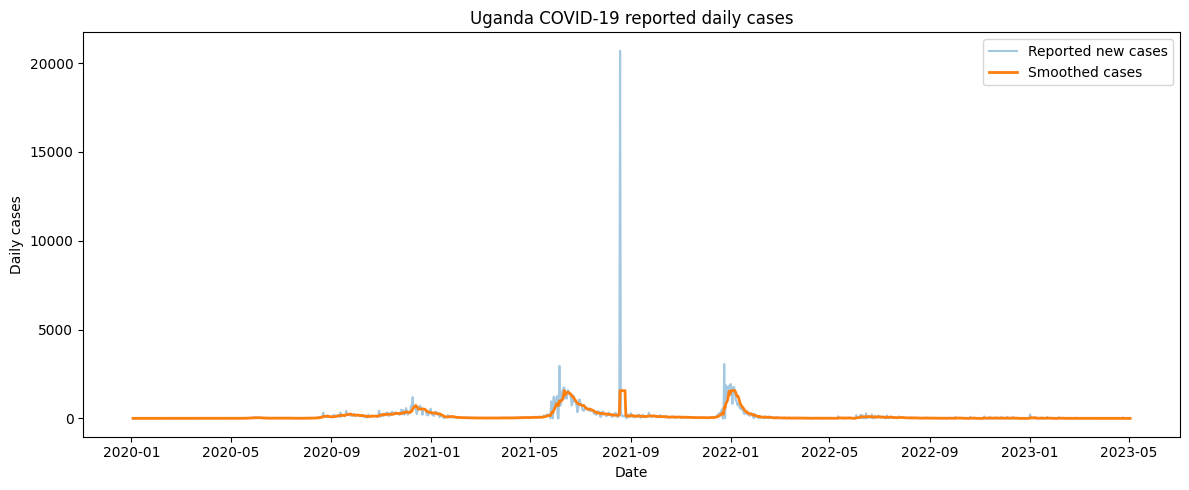

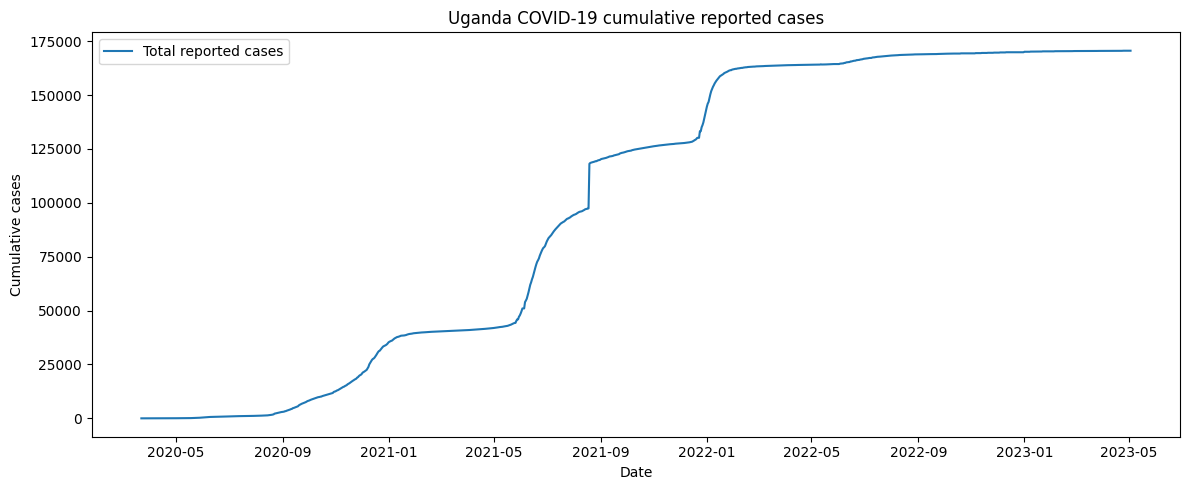

In [ ]:
#plots
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["new_cases"], alpha=0.4, label="Reported new cases")
plt.plot(df["date"], df["cases_for_model"], linewidth=2, label="Smoothed cases")
plt.xlabel("Date")
plt.ylabel("Daily cases")
plt.title("Uganda COVID-19 reported daily cases")
plt.legend()
plt.tight_layout()
plt.show()

if "total_cases" in df.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["total_cases"], label="Total reported cases")
    plt.xlabel("Date")
    plt.ylabel("Cumulative cases")
    plt.title("Uganda COVID-19 cumulative reported cases")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
 #Define the SEIR model
def seir_model(y, t, beta, sigma, gamma, N):
    """
    SEIR model compartments:
    S = Susceptible
    E = Exposed but not yet infectious
    I = Infectious
    R = Removed/recovered

    Parameters:
    beta  = transmission rate
    sigma = rate of progression from exposed to infectious
            1/sigma is the average incubation period
    gamma = recovery/removal rate
            1/gamma is the average infectious period
    N     = total population
    """
    S, E, I, R = y

    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return [dSdt, dEdt, dIdt, dRdt]



In [ ]:
def simulate_seir(params, t, N):
    """
    Simulate SEIR model and return predicted daily new infections.

    params = [beta, sigma, gamma, E0, I0]
    """
    beta, sigma, gamma, E0, I0 = params

    R0_initial = 0
    S0 = N - E0 - I0 - R0_initial

    y0 = [S0, E0, I0, R0_initial]

    solution = odeint(seir_model, y0, t, args=(beta, sigma, gamma, N))
    S, E, I, R = solution.T

    # New infections are movement from S to E:
    # beta*S*I/N
    predicted_new_infections = beta * S * I / N

    return predicted_new_infections, solution

In [ ]:

model_df = df.copy()
observed_cases = model_df["cases_for_model"].values
t = np.arange(len(model_df))

In [ ]:
def loss_function(params, t, observed_cases, N):
    """
    Objective function to minimize.
    Uses mean squared error between observed and predicted daily cases.
    """
    beta, sigma, gamma, E0, I0 = params

    # Penalize biologically implausible values
    if beta <= 0 or sigma <= 0 or gamma <= 0 or E0 < 1 or I0 < 1:
        return np.inf

    predicted, _ = simulate_seir(params, t, N)

    # Scale prediction because reported cases are usually lower than true infections.
    # Here, we fit directly to reported cases for simplicity.
    mse = mean_squared_error(observed_cases, predicted)

    return mse


In [ ]:
# Initial parameter guesses
# beta: transmission rate
# sigma: 1/incubation period, e.g. 1/5
# gamma: 1/infectious period, e.g. 1/7
# E0 and I0: initial exposed and infectious individuals
initial_guess = [0.3, 1/5, 1/7, 50, 20]

# Bounds
bounds = [
    (0.01, 2.0),     # beta
    (1/14, 1/2),     # sigma: incubation period between 2 and 14 days
    (1/21, 1/3),     # gamma: infectious period between 3 and 21 days
    (1, 10000),      # E0
    (1, 10000)       # I0
]

result = minimize(
    loss_function,
    initial_guess,
    args=(t, observed_cases, N),
    bounds=bounds,
    method="L-BFGS-B"
)

best_params = result.x
beta_hat, sigma_hat, gamma_hat, E0_hat, I0_hat = best_params

In [ ]:
print("\nFitted parameters")
print("")
print(f"Beta:  {beta_hat:.4f}")
print(f"Sigma: {sigma_hat:.4f}  -> incubation period ≈ {1/sigma_hat:.1f} days")
print(f"Gamma: {gamma_hat:.4f}  -> infectious period ≈ {1/gamma_hat:.1f} days")
print(f"Initial exposed E0:   {E0_hat:.0f}")
print(f"Initial infectious I0:{I0_hat:.0f}")

# Basic reproduction number
R0_estimated = beta_hat / gamma_hat
print(f"Estimated basic reproduction number R0 ≈ {R0_estimated:.2f}")


Fitted SEIR parameters

Beta:  0.0100
Sigma: 0.0714  -> incubation period ≈ 14.0 days
Gamma: 0.3333  -> infectious period ≈ 3.0 days
Initial exposed E0:   1
Initial infectious I0:10000
Estimated basic reproduction number R0 ≈ 0.03


In [ ]:
#Generate values
predicted_cases, solution = simulate_seir(best_params, t, N)
S, E, I, R = solution.T

mae = mean_absolute_error(observed_cases, predicted_cases)
rmse = np.sqrt(mean_squared_error(observed_cases, predicted_cases))

print("\nModel performance")
print("")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Model performance

MAE:  131.53
RMSE: 306.80


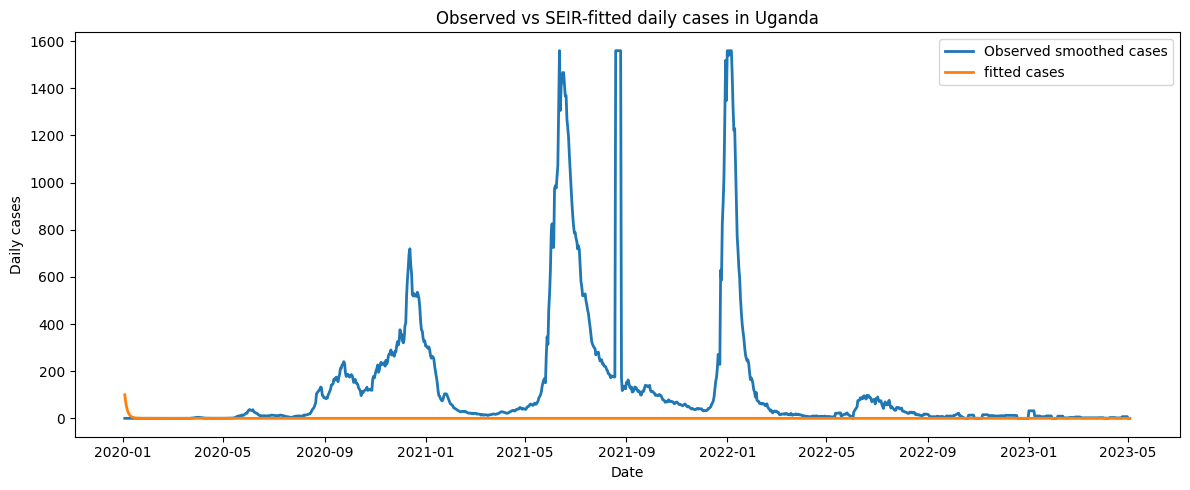

In [ ]:
#Plot observed vs fitted cases
plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], observed_cases, label="Observed smoothed cases", linewidth=2)
plt.plot(model_df["date"], predicted_cases, label="fitted cases", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Daily cases")
plt.title("Observed vs SEIR-fitted daily cases in Uganda")
plt.legend()
plt.tight_layout()
plt.show()


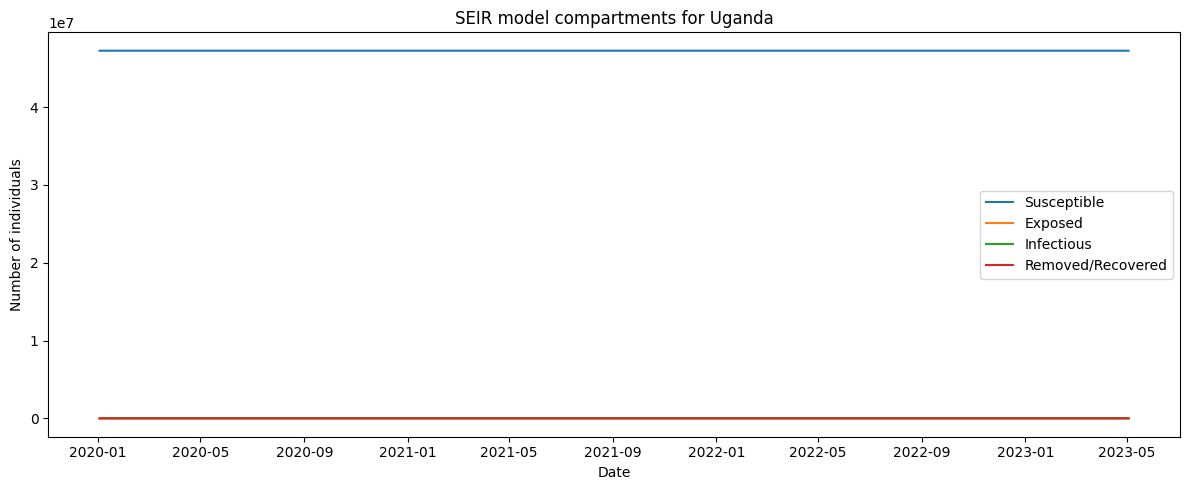

In [ ]:
#  Plot Compartments
plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], S, label="Susceptible")
plt.plot(model_df["date"], E, label="Exposed")
plt.plot(model_df["date"], I, label="Infectious")
plt.plot(model_df["date"], R, label="Removed/Recovered")
plt.xlabel("Date")
plt.ylabel("Number of individuals")
plt.title("SEIR model compartments for Uganda")
plt.legend()
plt.tight_layout()
plt.show()


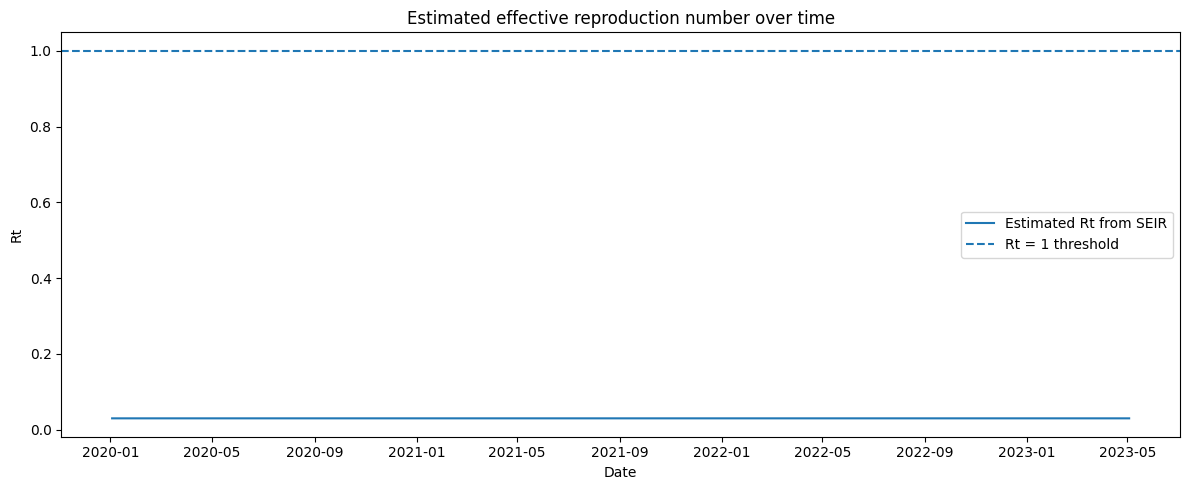

In [ ]:
# Estimate time-varying effective reproduction number
# In a basic SEIR model, effective Rt can be approximated as:
# Rt = R0 * S(t)/N
Rt = R0_estimated * (S / N)

plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], Rt, label="Estimated Rt from SEIR")
plt.axhline(1, linestyle="--", label="Rt = 1 threshold")
plt.xlabel("Date")
plt.ylabel("Rt")
plt.title("Estimated effective reproduction number over time")
plt.legend()
plt.tight_layout()
plt.show()


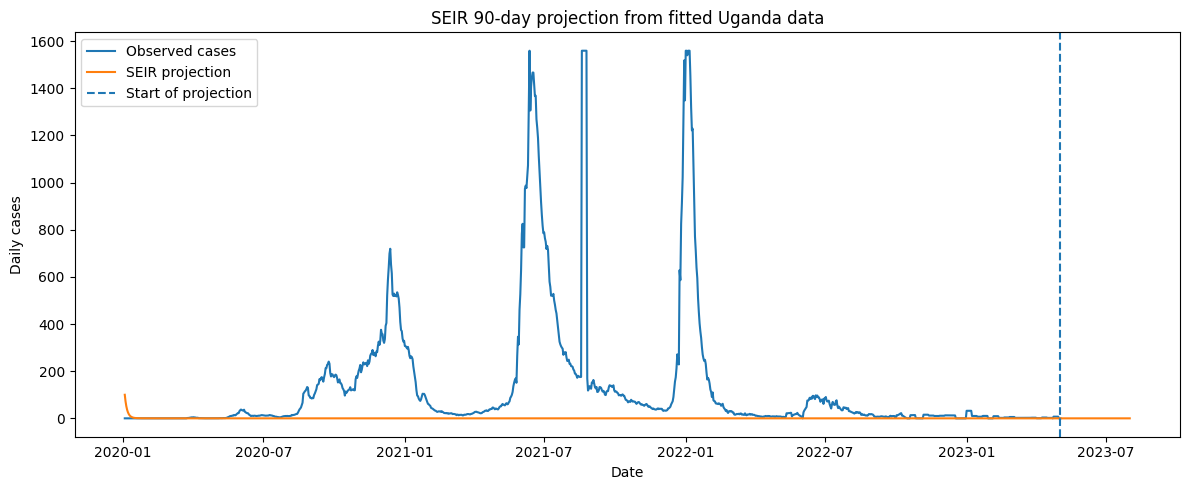

In [ ]:
#Future Projections
future_days = 90
t_future = np.arange(len(model_df) + future_days)

pred_future, sol_future = simulate_seir(best_params, t_future, N)
S_f, E_f, I_f, R_f = sol_future.T

future_dates = pd.date_range(
    start=model_df["date"].iloc[0],
    periods=len(t_future),
    freq="D"
)

plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], observed_cases, label="Observed cases")
plt.plot(future_dates, pred_future, label="SEIR projection")
plt.axvline(model_df["date"].iloc[-1], linestyle="--", label="Start of projection")
plt.xlabel("Date")
plt.ylabel("Daily cases")
plt.title("SEIR 90-day projection from fitted Uganda data")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Model output
output = model_df[["date", "new_cases", "cases_for_model"]].copy()
output["seir_fitted_cases"] = predicted_cases
output["S"] = S
output["E"] = E
output["I"] = I
output["R"] = R
output["Rt"] = Rt

output.to_csv("uganda_seir_model_output.csv", index=False)

print("\nSaved output file: uganda_seir_model_output.csv")


Saved output file: uganda_seir_model_output.csv


In [ ]:
print("\nInterpretation")
print("")
print("1. Beta represents how fast infection is transmitted.")
print("2. Sigma represents movement from exposed to infectious.")
print("3. Gamma represents recovery/removal from infection.")
print("4. R0 = beta/gamma. If R0 > 1, infections can grow; if R0 < 1, infections decline.")
print("5. Rt adjusts R0 by the remaining susceptible population.")
print("6. Because this model uses reported cases, under-reporting and testing changes may bias estimates.")



Interpretation

1. Beta represents how fast infection is transmitted.
2. Sigma represents movement from exposed to infectious.
3. Gamma represents recovery/removal from infection.
4. R0 = beta/gamma. If R0 > 1, infections can grow; if R0 < 1, infections decline.
5. Rt adjusts R0 by the remaining susceptible population.
6. Because this model uses reported cases, under-reporting and testing changes may bias estimates.


## **Conclusion**
This project presents a comprehensive analysis of infectious disease dynamics in Uganda using both data-driven epidemiological methods and a compartmental SEIR model. The analysis begins with cleaning and exploring time-series case data to understand underlying trends and reporting patterns.

It also quantifies epidemic behavior by estimating key metrics such as the growth rate, doubling time, and the time-varying reproduction number (Rt), which together describe how transmission evolves over time. Wave detection techniques are applied to identify distinct phases of the epidemic, allowing comparison of transmission intensity across different periods.

An SEIR model is then fitted to the observed data to estimate transmission (β), incubation (σ), and recovery (γ) parameters. Model performance is assessed through diagnostic checks, including comparisons between observed and predicted cases. To evaluate robustness, sensitivity analyses are conducted by varying key parameters and observing their impact on epidemic trajectories.
Finally, it is used to simulate future scenarios under different transmission assumptions, providing insight into potential outbreak trajectories and the impact of interventions.
